<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/08-academico/calcnum-rk4-euler-eletricas/calcnum-rk4-euler-eletricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def runge_kutta_4(f, x0, y0, h, n):
    """
    Método de Runge-Kutta de 4ª ordem

    Parâmetros:
    f: função f(x, y) = dy/dx
    x0: valor inicial de x
    y0: valor inicial de y
    h: passo
    n: número de passos

    Retorna:
    x: array com os valores de x
    y: array com os valores de y
    """
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)

    x[0] = x0
    y[0] = y0

    for i in range(n):
        k1 = h * f(x[i], y[i])
        k2 = h * f(x[i] + h/2, y[i] + k1/2)
        k3 = h * f(x[i] + h/2, y[i] + k2/2)
        k4 = h * f(x[i] + h, y[i] + k3)

        y[i + 1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
        x[i + 1] = x[i] + h

    return x, y

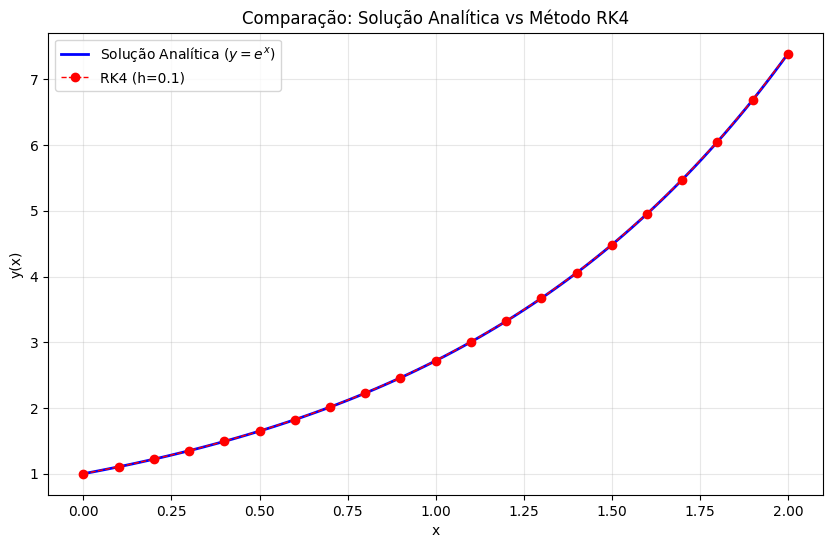

Erro máximo: 1.13e-05
Erro médio: 3.34e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a EDO
def f(x, y):
    return y

# Solução analítica
def sol_analitica(x):
    return np.exp(x)

# Parâmetros
x0, y0 = 0, 1
h = 0.1
n = 20

# Aplicando RK4
x_rk, y_rk = runge_kutta_4(f, x0, y0, h, n)

# Gerando pontos analíticos
x_analitico = np.linspace(0, 2, 100)
y_analitico = sol_analitica(x_analitico)

# Plotando
plt.figure(figsize=(10, 6))
plt.plot(x_analitico, y_analitico, 'b-', linewidth=2, label='Solução Analítica ($y = e^x$)')
plt.plot(x_rk, y_rk, 'ro--', linewidth=1, markersize=6, label='RK4 (h=0.1)')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Comparação: Solução Analítica vs Método RK4')
plt.legend()
plt.show()

# Calculando erro
y_exato = sol_analitica(x_rk)
erro = np.abs(y_rk - y_exato)
print(f"Erro máximo: {np.max(erro):.2e}")
print(f"Erro médio: {np.mean(erro):.2e}")

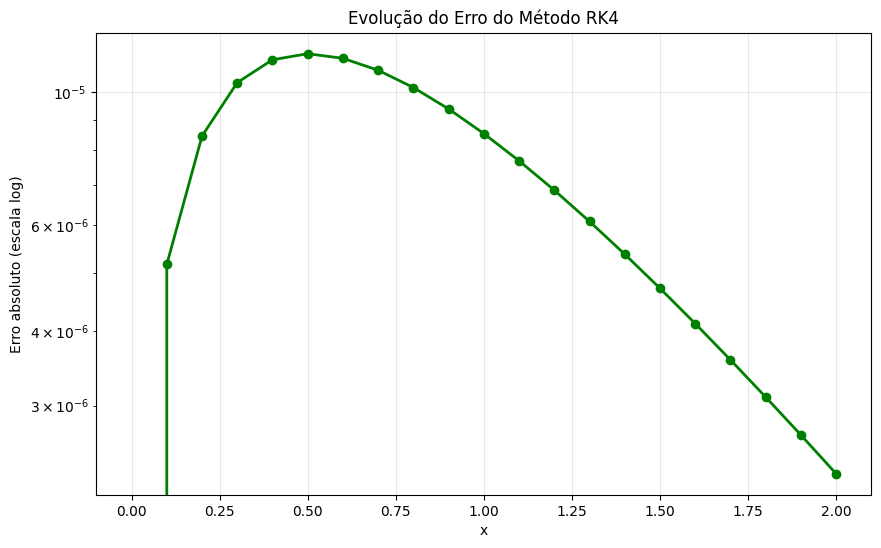

In [ ]:
# Análise adicional do erro
plt.figure(figsize=(10, 6))
plt.semilogy(x_rk, erro, 'go-', linewidth=2, markersize=6)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('Erro absoluto (escala log)')
plt.title('Evolução do Erro do Método RK4')
plt.show()

COMPARAÇÃO: EULER vs RUNGE-KUTTA (h = 0.23)
x		Euler		RK4		Analítico
-------------------------------------------------------
0.00		1.000000	1.000000	1.000000
0.23		1.230000	1.258594	1.258600
0.46		1.512900	1.584060	1.584074
0.69		1.860867	1.993689	1.993716
0.92		2.288866	2.509246	2.509290
1.15		2.815306	3.158123	3.158193
1.38		3.462826	3.974796	3.974902
1.61		4.259276	5.002656	5.002811
1.84		5.238909	6.296315	6.296538
2.07		6.443859	7.924507	7.924823
2.30		7.925946	9.973741	9.974182


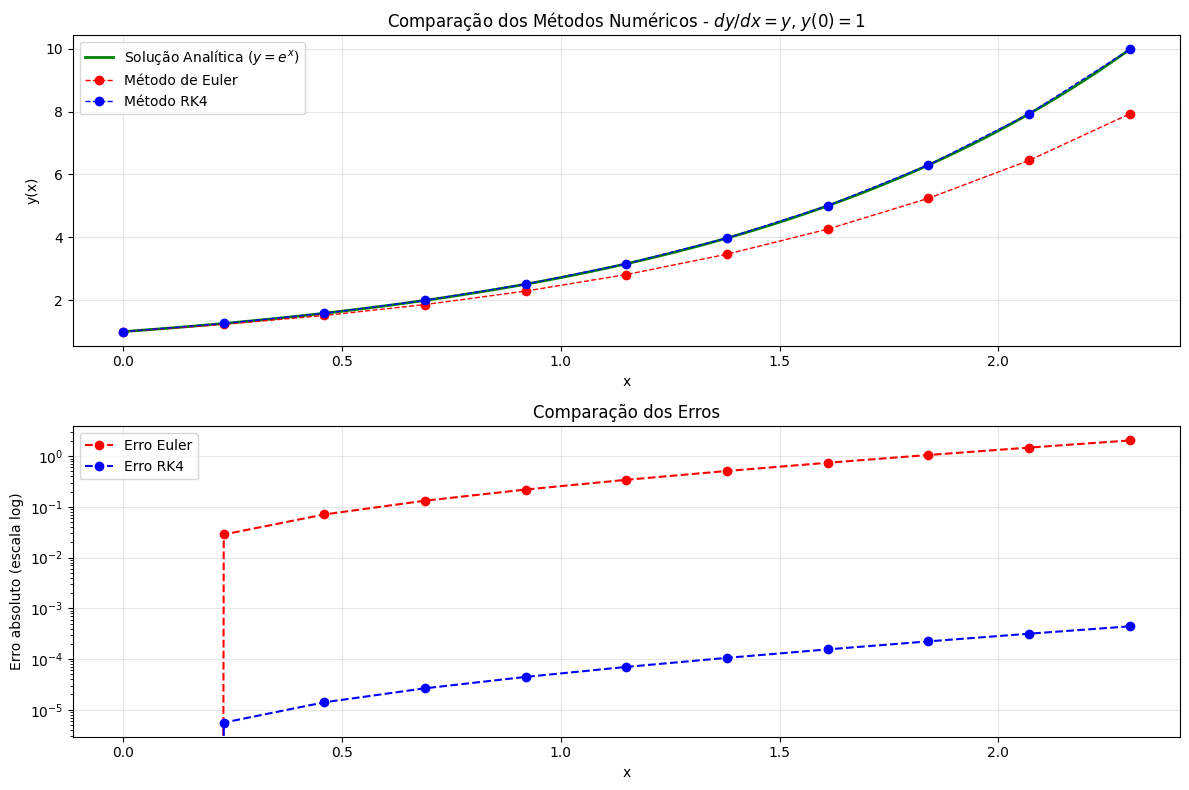


ESTATÍSTICAS DOS ERROS:
Euler - Erro máximo: 2.05e+00
Euler - Erro médio: 6.03e-01
RK4   - Erro máximo: 4.42e-04
RK4   - Erro médio: 1.27e-04


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def runge_kutta_4(f, x0, y0, h, n):
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)

    x[0] = x0
    y[0] = y0

    for i in range(n):
        k1 = h * f(x[i], y[i])
        k2 = h * f(x[i] + h/2, y[i] + k1/2)
        k3 = h * f(x[i] + h/2, y[i] + k2/2)
        k4 = h * f(x[i] + h, y[i] + k3)

        y[i + 1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
        x[i + 1] = x[i] + h

    return x, y

def euler_method(f, x0, y0, h, n):
    x = np.zeros(n + 1)
    y = np.zeros(n + 1)

    x[0] = x0
    y[0] = y0

    for i in range(n):
        y[i + 1] = y[i] + h * f(x[i], y[i])
        x[i + 1] = x[i] + h

    return x, y

# EDO: dy/dx = y
def f(x, y):
    return y

# Solução analítica: y = e^x
def sol_analitica(x):
    return np.exp(x)

# Parâmetros (iguais ao GeoGebra)
x0, y0 = 0, 1
h = 0.23
n = 10

# Aplicando os métodos
x_rk, y_rk = runge_kutta_4(f, x0, y0, h, n)
x_euler, y_euler = euler_method(f, x0, y0, h, n)

# Resultados para comparação
print("COMPARAÇÃO: EULER vs RUNGE-KUTTA (h = 0.23)")
print("x\t\tEuler\t\tRK4\t\tAnalítico")
print("-" * 55)
for i in range(len(x_rk)):
    exact = sol_analitica(x_rk[i])
    print(f"{x_rk[i]:.2f}\t\t{y_euler[i]:.6f}\t{y_rk[i]:.6f}\t{exact:.6f}")

# Plot comparativo
x_analitico = np.linspace(0, x_rk[-1], 100)
y_analitico = sol_analitica(x_analitico)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(x_analitico, y_analitico, 'g-', linewidth=2, label='Solução Analítica ($y = e^x$)')
plt.plot(x_euler, y_euler, 'ro--', linewidth=1, markersize=6, label='Método de Euler')
plt.plot(x_rk, y_rk, 'bo--', linewidth=1, markersize=6, label='Método RK4')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Comparação dos Métodos Numéricos - $dy/dx = y$, $y(0) = 1$')
plt.legend()

# Erros
plt.subplot(2, 1, 2)
erro_euler = np.abs(y_euler - sol_analitica(x_euler))
erro_rk4 = np.abs(y_rk - sol_analitica(x_rk))

plt.semilogy(x_euler, erro_euler, 'ro--', label='Erro Euler', markersize=6)
plt.semilogy(x_rk, erro_rk4, 'bo--', label='Erro RK4', markersize=6)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('Erro absoluto (escala log)')
plt.title('Comparação dos Erros')
plt.legend()

plt.tight_layout()
plt.show()

# Estatísticas dos erros
print(f"\nESTATÍSTICAS DOS ERROS:")
print(f"Euler - Erro máximo: {np.max(erro_euler):.2e}")
print(f"Euler - Erro médio: {np.mean(erro_euler):.2e}")
print(f"RK4   - Erro máximo: {np.max(erro_rk4):.2e}")
print(f"RK4   - Erro médio: {np.mean(erro_rk4):.2e}")

Gerando diagrama do Sistema B...

Diagrama do Sistema B salvo como 'diagramas_sistemas.png'
Resolução: 300 DPI (adequada para relatório)


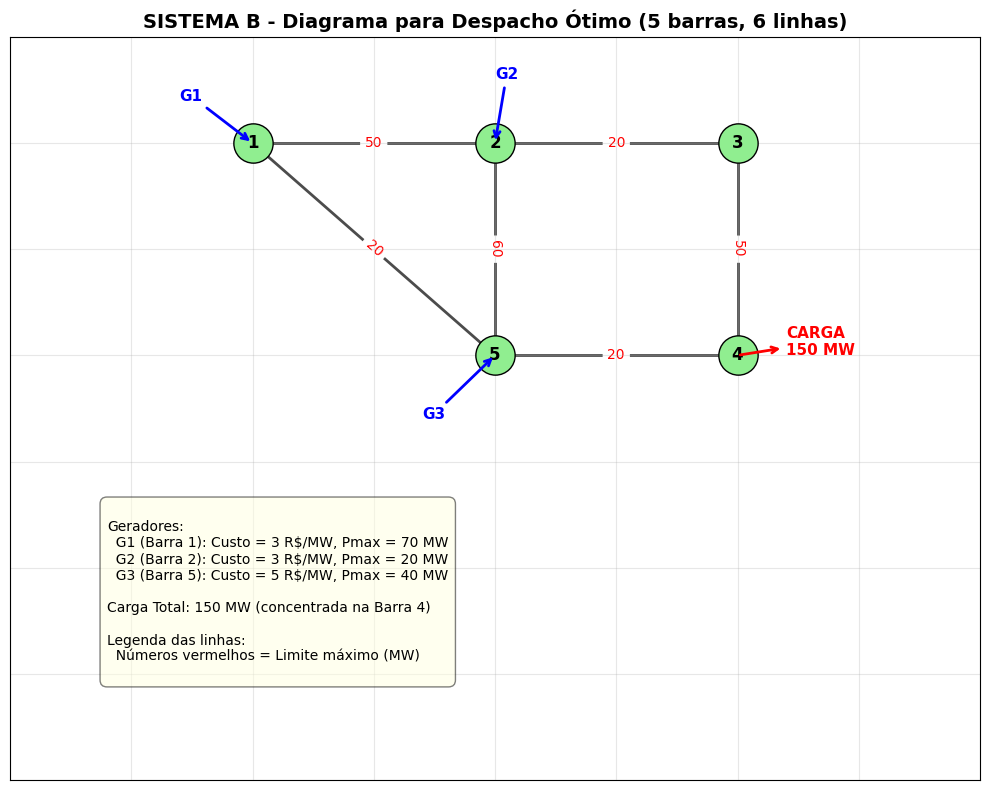


Gerando diagrama do Sistema 1 com fluxos...
Diagrama com fluxos salvo como 'sistema1_com_fluxos.png'


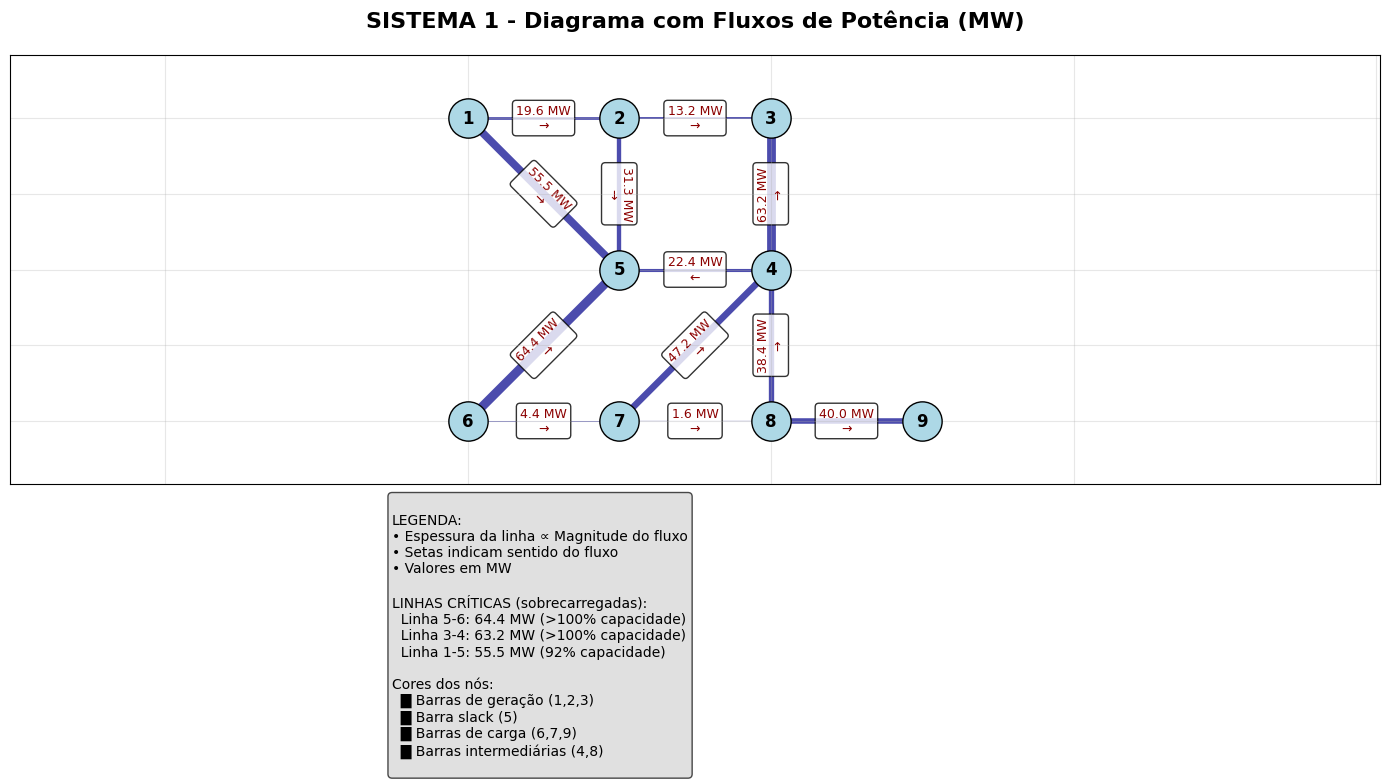

In [ ]:
# -*- coding: utf-8 -*-
"""
BCTEC022 - Diagramas dos Sistemas Elétricos
Sistema 1 (Parte A) e Sistema B (Parte B)

Este código gera diagramas unifilares para os sistemas estudados.
"""

import matplotlib.pyplot as plt
import networkx as nx

# ============================================
# DEFINIÇÕES GERAIS PARA SISTEMA 1 (mantidas para uso posterior)
# ============================================
# Criar grafo para Sistema 1
G1 = nx.Graph()

# Adicionar nós (barras)
barras_s1 = [1, 2, 3, 4, 5, 6, 7, 8, 9]
G1.add_nodes_from(barras_s1)

# Adicionar arestas (linhas)
linhas_s1 = [
    (1, 2), (1, 5), (2, 3), (2, 5),
    (3, 4), (4, 5), (4, 7), (4, 8),
    (5, 6), (6, 7), (7, 8), (8, 9)
]
G1.add_edges_from(linhas_s1)

# Posições dos nós para melhor visualização
pos_s1 = {
    1: (0, 2),    # Topo esquerdo
    2: (1, 2),    # Topo meio
    3: (2, 2),    # Topo direito
    4: (2, 1),    # Centro direito
    5: (1, 1),    # Centro
    6: (0, 0),    # Baixo esquerdo
    7: (1, 0),    # Baixo centro
    8: (2, 0),    # Baixo direito
    9: (3, 0)     # Extremo direito
}

# ============================================
# DIAGRAMA DO SISTEMA B
# ============================================
print("Gerando diagrama do Sistema B...")

# Criar grafo
G2 = nx.Graph()

# Adicionar nós (barras)
barras_b = [1, 2, 3, 4, 5]
G2.add_nodes_from(barras_b)

# Adicionar arestas (linhas) com pesos (limites)
linhas_b = [
    (1, 2, 50), (1, 5, 20), (2, 3, 20),
    (2, 5, 60), (3, 4, 50), (4, 5, 20)
]
G2.add_weighted_edges_from(linhas_b)

# Posições dos nós
pos_b = {
    1: (0, 1),    # Esquerda
    2: (1, 1),    # Centro superior
    3: (2, 1),    # Direita superior
    4: (2, 0),    # Direita inferior
    5: (1, 0)     # Centro inferior
}

# Criar figura para o Sistema B
plt.figure(figsize=(10, 8)) # Aumentei o figsize para dar mais espaço

plt.title("SISTEMA B - Diagrama para Despacho Ótimo (5 barras, 6 linhas)",
          fontsize=14, fontweight='bold')

# Desenhar rede
nx.draw_networkx_nodes(G2, pos_b, node_size=800,
                      node_color='lightgreen', edgecolors='black')
nx.draw_networkx_edges(G2, pos_b, width=2, alpha=0.7)

# Desenhar labels das barras
nx.draw_networkx_labels(G2, pos_b, font_size=12, font_weight='bold')

# Adicionar labels das linhas (limites)
edge_labels = nx.get_edge_attributes(G2, 'weight')
nx.draw_networkx_edge_labels(G2, pos_b, edge_labels=edge_labels,
                            font_size=10, font_color='red')

# Adicionar informações dos geradores
geradores_info = """
Geradores:
  G1 (Barra 1): Custo = 3 R$/MW, Pmax = 70 MW
  G2 (Barra 2): Custo = 3 R$/MW, Pmax = 20 MW
  G3 (Barra 5): Custo = 5 R$/MW, Pmax = 40 MW

Carga Total: 150 MW (concentrada na Barra 4)

Legenda das linhas:
  Números vermelhos = Limite máximo (MW)
"""
plt.text(-0.6, -0.7, geradores_info, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5, pad=0.5))

# Adicionar setas indicando geradores
plt.annotate('G1', xy=(0, 1), xytext=(-0.3, 1.2),
             arrowprops=dict(arrowstyle='->', lw=2, color='blue'),
             fontsize=11, fontweight='bold', color='blue')

plt.annotate('G2', xy=(1, 1), xytext=(1, 1.3),
             arrowprops=dict(arrowstyle='->', lw=2, color='blue'),
             fontsize=11, fontweight='bold', color='blue')

plt.annotate('G3', xy=(1, 0), xytext=(0.7, -0.3),
             arrowprops=dict(arrowstyle='->', lw=2, color='blue'),
             fontsize=11, fontweight='bold', color='blue')

# Adicionar carga
plt.annotate('CARGA\n150 MW', xy=(2, 0), xytext=(2.2, 0),
             arrowprops=dict(arrowstyle='<-', lw=2, color='red'),
             fontsize=11, fontweight='bold', color='red')

plt.grid(True, alpha=0.3)
# Removendo plt.axis('equal') para permitir que xlim e ylim sejam respeitados
plt.xlim(-1.0, 3.0)
plt.ylim(-2.0, 1.5) # Ajustei os limites Y para dar mais espaço à legenda

# SALVAR E MOSTRAR (Sistema B agora é único para diagramas_sistemas.png)
plt.tight_layout()
plt.savefig('diagramas_sistemas.png', dpi=300, bbox_inches='tight')
print("\nDiagrama do Sistema B salvo como 'diagramas_sistemas.png'")
print("Resolução: 300 DPI (adequada para relatório)")

plt.show()

# ============================================
# DIAGRAMA COM FLUXOS DO SISTEMA 1
# ============================================
print("\nGerando diagrama do Sistema 1 com fluxos...")

# Valores de fluxo calculados (em MW)
fluxos_s1 = {
    (1, 2): 19.55,
    (1, 5): 55.45,
    (2, 3): 13.23,
    (2, 5): 31.32,
    (3, 4): 63.23,
    (4, 5): -22.36,  # Negativo indica sentido contrário
    (4, 7): 47.20,
    (4, 8): 38.40,
    (5, 6): 64.41,
    (6, 7): 4.41,
    (7, 8): 1.60,
    (8, 9): 40.00
}

plt.figure(figsize=(14, 8))
plt.title("SISTEMA 1 - Diagrama com Fluxos de Potência (MW)",
          fontsize=16, fontweight='bold', pad=20)

# Desenhar nós
nx.draw_networkx_nodes(G1, pos_s1, node_size=800,
                      node_color='lightblue', edgecolors='black')

# Desenhar arestas com espessura proporcional ao fluxo
edge_widths = []
for edge in G1.edges():
    # Obter fluxo (valor absoluto para largura)
    if edge in fluxos_s1:
        width = abs(fluxos_s1[edge]) / 10  # Escala para visualização
    elif (edge[1], edge[0]) in fluxos_s1:
        width = abs(fluxos_s1[(edge[1], edge[0])]) / 10
    else:
        width = 1
    edge_widths.append(width)

nx.draw_networkx_edges(G1, pos_s1, width=edge_widths,
                      alpha=0.7, edge_color='darkblue')

# Desenhar labels
nx.draw_networkx_labels(G1, pos_s1, font_size=12, font_weight='bold')

# Adicionar valores de fluxo nas arestas
edge_labels = {}
for edge, fluxo in fluxos_s1.items():
    sentido = "→" if fluxo >= 0 else "←"
    edge_labels[edge] = f"{abs(fluxo):.1f} MW\n{sentido}"

nx.draw_networkx_edge_labels(G1, pos_s1, edge_labels=edge_labels,
                            font_size=9, font_color='darkred',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Legenda de cores para fluxo
legenda_texto = """
LEGENDA:
• Espessura da linha ∝ Magnitude do fluxo
• Setas indicam sentido do fluxo
• Valores em MW

LINHAS CRÍTICAS (sobrecarregadas):
  Linha 5-6: 64.4 MW (>100% capacidade)
  Linha 3-4: 63.2 MW (>100% capacidade)
  Linha 1-5: 55.5 MW (92% capacidade)

Cores dos nós:
  █ Barras de geração (1,2,3)
  █ Barra slack (5)
  █ Barras de carga (6,7,9)
  █ Barras intermediárias (4,8)
"""
plt.text(-0.5, -0.5, legenda_texto, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-1, 4)
plt.ylim(-1, 3)

# Salvar
plt.tight_layout()
plt.savefig('sistema1_com_fluxos.png', dpi=300, bbox_inches='tight')
print("Diagrama com fluxos salvo como 'sistema1_com_fluxos.png'")

plt.show()
